<a href="https://colab.research.google.com/github/EduRubira2/Rubira_lib/blob/main/Secante.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nome: <font color="red">**Eduardo Nunes Rubira**</font>\
Matrícula:<font color="red"> **169555**</font>\
Método: <font color="red">**Método da secante**</font>


Resumo: ***O método da secante necessita de dois chutes iniciais, sendo comparado com newton-raphson, a derivada pode vir a ser um problema, logo, o método da secante solucionaria isso, utilizando o i e o anterior por ser regressivo, ***

  MÉTODO DA SECANTE — Raiz de f(x) = e^(-x) - x
  Primeiro chute inicial x0            : 0
  Segundo chute inicial x1             : 1
  Tolerância percentual (ex: 0.0001)   : 0.0001
  Número máximo de iterações           : 3
  x0 = 0.0  |  x1 = 1.0  |  Tolerância: 0.0001%  |  Max iter: 3
Aviso: número máximo de iterações atingido sem convergência.

Histórico de iterações:
-----------------------------------------------------------------------------------
 iter |            x0 |            x1 |         f(x1) |            x2 |      εa (%)
-----------------------------------------------------------------------------------
    1 |     0.0000000 |     1.0000000 |    -0.6321206 |     0.6126998 |    63.21206
    2 |     1.0000000 |     0.6126998 |    -0.0708139 |     0.5638384 |     8.66586
    3 |     0.6126998 |     0.5638384 |     0.0051824 |     0.5671704 |     0.58747
-----------------------------------------------------------------------------------

  RESULTADOS
  [Obrigatório] Raiz en

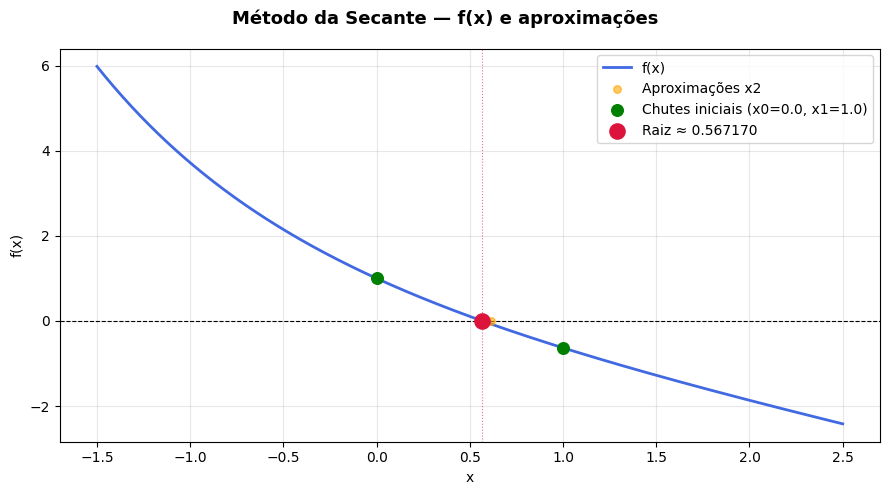

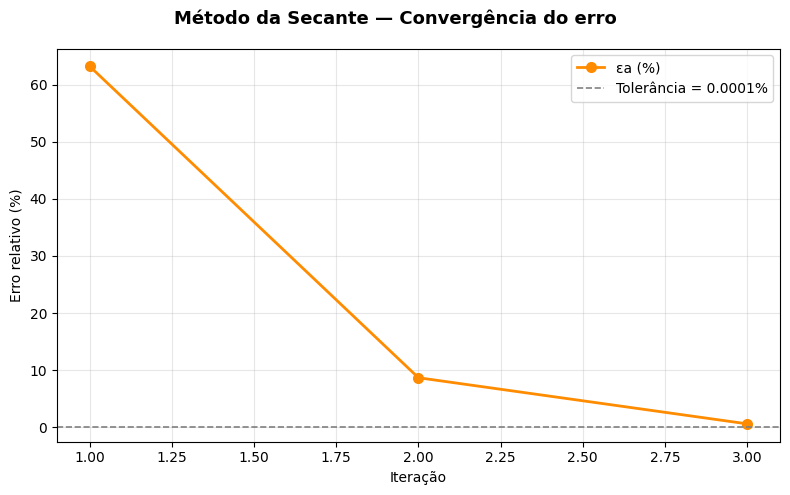

In [14]:
"""
================================================================================
MÉTODO DA SECANTE — Raízes de f(x) = 0
================================================================================
Disciplina : Métodos Numéricos
Autor      : Eduardo Nunes Rubira
Matrícula  : 169555
Data       : 2026-04-28
================================================================================

DESCRIÇÃO DO PROBLEMA:
    O Método da Secante encontra raízes de f(x) = 0 sem precisar calcular
    a derivada. Em vez de usar a tangente (como Newton-Raphson), usa a reta
    que passa pelos dois últimos pontos — chamada de SECANTE:

        x2 = x1 - f(x1) * (x0 - x1) / (f(x0) - f(x1))

    Vantagem sobre Newton-Raphson : não exige f'(x)
    Desvantagem em relação a Newton: exige DOIS chutes iniciais (x0 e x1)

RELAÇÃO COM OS OUTROS MÉTODOS JÁ VISTOS:
    Bissecção      → divide intervalo ao meio, lento mas seguro
    Ponto Fixo     → itera g(x), você escolhe a reformulação
    Newton-Raphson → usa tangente (deriva f), convergência quadrática
    Secante        → usa secante (sem derivada), convergência superlinear

ENTRADAS:
    f        → função f(x) cuja raiz se deseja encontrar
    x0       → primeiro chute inicial
    x1       → segundo chute inicial (diferente de x0)
    tol      → tolerância do erro relativo percentual (%)
    max_iter → número máximo de iterações

SAÍDAS:
    Obrigatórias:
        x2        → aproximação da raiz encontrada
        iterações → número de iterações realizadas
        aviso     → mensagem se não convergir

    Opcionais (todas implementadas):
        1. Tabela com x0, x1, f(x1), x2 e εa(%) por iteração
        2. Gráfico de f(x) destacando a raiz encontrada e as aproximações
        3. Gráfico do erro relativo por iteração (convergência)
================================================================================
"""

# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import math                              # funções matemáticas nativas do Python: math.exp(), math.sin(), math.log()…
import numpy as np                       # numpy: cálculo numérico vetorizado (arrays, linspace, etc.); apelido "np"
import matplotlib.pyplot as plt          # matplotlib: biblioteca de gráficos; usamos só o módulo pyplot, apelido "plt"
from typing import Callable, List, Dict  # typing: permite declarar os tipos dos argumentos das funções (type hints)
                                         # Callable = "é uma função", List = "é uma lista", Dict = "é um dicionário"


# ==============================================================================
# 2. FUNÇÃO DO PROBLEMA
# ==============================================================================

def f(x: float) -> float:               # define a função f; "x: float" diz que x é número decimal; "-> float" diz o que retorna
    """
    Função cujo zero desejamos encontrar.

    Para trocar o problema, basta editar o return abaixo.
    O resto do código não precisa ser alterado.

    Função atual: f(x) = e^(-x) - x
    Raiz esperada: x ≈ 0.5671

    Parâmetros
    ----------
    x : float → ponto de avaliação

    Retorna
    -------
    float → valor de f(x)
    """
    return math.exp(-x) - x            # math.exp(-x) calcula e^(-x); subtrai x; troque esta linha para mudar o problema


# ==============================================================================
# 3. IMPLEMENTAÇÃO DO MÉTODO
# ==============================================================================

def secante(                             # início da definição da função "secante" — os argumentos ficam nas linhas abaixo
    f: Callable[[float], float],         # f é uma função que recebe um float e devolve um float (a função do problema)
    x0: float,                           # x0: primeiro chute inicial fornecido pelo usuário
    x1: float,                           # x1: segundo chute inicial fornecido pelo usuário (deve ser diferente de x0)
    tol: float,                          # tol: tolerância — o loop para quando o erro ficar abaixo deste valor
    max_iter: int                        # max_iter: número máximo de iterações permitidas para evitar loop infinito
) -> tuple[float, List[Dict]]:           # tipo do retorno: uma tupla com (float, lista de dicionários)
    """
    Método da Secante para encontrar raízes de f(x) = 0.

    Fórmula de iteração (enunciado FURG):
        x2 = x1 - f(x1) * (x0 - x1) / (f(x0) - f(x1))

    Parâmetros
    ----------
    f        : Callable → função f(x) contínua
    x0       : float    → primeiro chute inicial
    x1       : float    → segundo chute inicial
    tol      : float    → tolerância do erro relativo percentual (%)
    max_iter : int      → número máximo de iterações permitidas

    Retorna
    -------
    x2     : float      → melhor aproximação da raiz encontrada
    tabela : List[Dict] → histórico completo com dados de cada iteração

    Levanta
    -------
    ValueError
        Se x0 == x1 (chutes iguais: a secante entre dois pontos iguais não existe).
    ZeroDivisionError
        Se f(x0) - f(x1) ≈ 0 durante o processo (reta secante quase horizontal).
    """

    # --- Validação: os dois chutes precisam ser diferentes ---
    if x0 == x1:                         # compara se x0 e x1 são iguais
        raise ValueError(                # raise interrompe o programa e lança um erro com mensagem explicativa
            "x0 e x1 devem ser diferentes.\n"           # primeira linha da mensagem de erro
            f"Recebido: x0 = {x0}, x1 = {x1}"          # f-string: insere os valores reais na mensagem
        )

    tabela: List[Dict] = []              # cria lista vazia que vai receber um dicionário por iteração

    # Renomeamos para xa e xb internamente para não confundir com os parâmetros x0 e x1
    # xa = x0 do enunciado (ponto mais antigo), xb = x1 do enunciado (ponto mais recente)
    xa = x0                              # xa guarda o primeiro chute — será o "x0" dentro do loop
    xb = x1                              # xb guarda o segundo chute — será o "x1" dentro do loop

    for i in range(max_iter):            # range(max_iter) gera os inteiros 0, 1, 2, … até max_iter-1
                                         # o loop executa no máximo max_iter vezes

        fa = f(xa)                       # avalia a função no ponto xa: calcula f(x0) da fórmula
        fb = f(xb)                       # avalia a função no ponto xb: calcula f(x1) da fórmula

        # --- Denominador da fórmula da secante: f(x0) - f(x1) ---
        diff_f = fa - fb                 # diferença entre os dois valores de f — é o denominador da fórmula

        if abs(diff_f) < 1e-12:          # abs() pega o valor absoluto; 1e-12 = 0.000000000001 (praticamente zero)
                                         # se diff_f for menor que isso, dividir por ele causaria erro numérico grave
            raise ZeroDivisionError(     # interrompe e lança erro com mensagem detalhada
                f"f(x0) - f(x1) ≈ 0 na iteração {i + 1}.\n"       # informa em qual iteração o problema ocorreu
                f"f({xb:.6f}) = {fb:.2e},  f({xa:.6f}) = {fa:.2e}\n"  # mostra os valores que causaram o problema
                "Escolha chutes iniciais diferentes."               # orientação para o usuário
            )

        # --- Fórmula da Secante: x2 = x1 - f(x1) * (x0 - x1) / (f(x0) - f(x1)) ---
        x2 = xb - fb * (xa - xb) / diff_f   # calcula a nova estimativa da raiz usando a fórmula do enunciado

        # --- Erro relativo percentual: |( x2 - x1 ) / x2| * 100 ---
        erro = abs((x2 - xb) / x2) * 100 if x2 != 0 else float("inf")
        # if x2 != 0: calcula normalmente; else: se x2 for zero, retorna infinito (evita divisão por zero)
        # abs() garante que o erro seja sempre positivo
        # * 100 converte de fração para porcentagem

        # --- Registra os dados desta iteração num dicionário e adiciona à lista ---
        tabela.append({                  # append() adiciona um novo elemento ao final da lista
            "iteração": i + 1,           # i começa em 0, somamos 1 para exibir a partir de 1 (mais natural)
            "x0":       xa,              # primeiro ponto usado na fórmula nesta iteração
            "x1":       xb,              # segundo ponto usado na fórmula nesta iteração
            "f(x1)":    fb,              # valor de f no segundo ponto — indica o quão longe estamos do zero
            "x2":       x2,              # nova estimativa calculada pela fórmula — saída obrigatória do enunciado
            "εa (%)":   erro,            # erro relativo percentual desta iteração — saída obrigatória do enunciado
        })

        # --- Critério de parada por tolerância ---
        if erro < tol:                   # se o erro já for menor que a tolerância definida pelo usuário
            break                        # break interrompe o for imediatamente — convergiu, não precisa continuar

        # --- Atualiza os pontos para a próxima iteração (passo d do enunciado FURG) ---
        xa = xb                          # x0 recebe x1: o ponto mais recente vira o mais antigo
        xb = x2                          # x1 recebe x2: a nova estimativa vira o ponto mais recente

    else:                                # este bloco só executa se o for terminou SEM break (não convergiu)
        print("Aviso: número máximo de iterações atingido sem convergência.")  # informa o usuário

    return x2, tabela                    # retorna a tupla: (melhor estimativa da raiz, histórico completo)


# ==============================================================================
# 4. SAÍDA FORMATADA
# ==============================================================================

def imprimir_tabela(tabela: List[Dict]) -> None:  # recebe a lista de dicionários; -> None significa que não retorna nada
    """
    [Saída opcional 2] Imprime o histórico de iterações em tabela alinhada.

    Usa f-strings com largura fixa (ex: :>13) para garantir que todas as
    colunas fiquem alinhadas independente do tamanho dos números.

    Parâmetros
    ----------
    tabela : List[Dict] → histórico retornado por secante()
    """

    # --- Monta o cabeçalho com larguras fixas ---
    # :>5 = alinha à direita em campo de 5 caracteres
    # :>13 = alinha à direita em campo de 13 caracteres
    cabecalho = (                        # parênteses permitem quebrar a string em várias linhas
        f"{'iter':>5} | "               # coluna do número da iteração, largura 5
        f"{'x0':>13} | "                # coluna de x0, largura 13
        f"{'x1':>13} | "                # coluna de x1, largura 13
        f"{'f(x1)':>13} | "             # coluna de f(x1), largura 13
        f"{'x2':>13} | "                # coluna de x2 (nova estimativa), largura 13
        f"{'εa (%)':>11}"               # coluna do erro relativo, largura 11
    )
    separador = "-" * len(cabecalho)    # cria uma linha de traços com o mesmo comprimento do cabeçalho
                                        # len() conta os caracteres; "-" * N repete o traço N vezes

    print(separador)                    # imprime a linha de traços acima do cabeçalho
    print(cabecalho)                    # imprime o cabeçalho com os nomes das colunas
    print(separador)                    # imprime a linha de traços abaixo do cabeçalho

    for linha in tabela:                # percorre cada dicionário da lista (um por iteração)
        print(                          # imprime uma linha da tabela para cada iteração
            f"{linha['iteração']:>5} | "       # número da iteração, 5 caracteres, alinhado à direita
            f"{linha['x0']:>13.7f} | "         # x0 com 7 casas decimais, campo de 13 caracteres
            f"{linha['x1']:>13.7f} | "         # x1 com 7 casas decimais, campo de 13 caracteres
            f"{linha['f(x1)']:>13.7f} | "      # f(x1) com 7 casas decimais, campo de 13 caracteres
            f"{linha['x2']:>13.7f} | "         # x2 com 7 casas decimais, campo de 13 caracteres
            f"{linha['εa (%)']:>11.5f}"        # erro com 5 casas decimais, campo de 11 caracteres
        )

    print(separador)                    # imprime a linha de traços abaixo da última linha de dados


# ==============================================================================
# 5. VISUALIZAÇÃO
# ==============================================================================

def plotar_funcao(                       # início da definição da função de gráfico
    f: Callable[[float], float],         # f: a função matemática que vamos plotar
    raiz: float,                         # raiz: ponto a marcar no gráfico como resultado final
    x0: float,                           # x0: primeiro chute inicial (usado para dimensionar a janela)
    x1: float,                           # x1: segundo chute inicial (usado para dimensionar a janela)
    tabela: List[Dict]                   # tabela: histórico de iterações (para mostrar as aproximações)
) -> None:                               # não retorna valor; apenas exibe o gráfico
    """
    [Saída opcional 2] Gráfico de f(x) com a raiz marcada e as aproximações
    intermediárias mostradas como pontos sobre o eixo x.

    Parâmetros
    ----------
    f       : Callable   → função f(x)
    raiz    : float      → raiz aproximada encontrada
    x0, x1  : float      → chutes iniciais (para dimensionar a janela)
    tabela  : List[Dict] → histórico de iterações
    """

    # --- Define a janela de visualização do gráfico ---
    extremos = [x0, x1, raiz]                                    # lista com os três pontos de referência
    margem   = max(abs(max(extremos) - min(extremos)) * 1.5, 1.5) # margem = 1.5x o intervalo entre os extremos, mínimo 1.5
                                                                  # max() garante que a margem nunca seja menor que 1.5
    x_min    = min(extremos) - margem                             # limite esquerdo do gráfico
    x_max    = max(extremos) + margem                             # limite direito do gráfico
    x_vals   = np.linspace(x_min, x_max, 500)                    # cria 500 pontos igualmente espaçados entre x_min e x_max

    f_vals = np.array([f(x) for x in x_vals], dtype=float)       # list comprehension: avalia f em cada um dos 500 pontos
                                                                  # np.array converte a lista para array numpy
                                                                  # dtype=float garante que NaN seja tratado corretamente

    fig, ax = plt.subplots(figsize=(9, 5))                        # cria figura (fig) com um painel de gráfico (ax)
                                                                  # figsize=(9,5): largura 9 polegadas, altura 5 polegadas
    fig.suptitle("Método da Secante — f(x) e aproximações",      # título principal da figura
                 fontsize=13, fontweight="bold")                  # tamanho 13 e negrito

    # --- Plota a curva de f(x) ---
    ax.plot(x_vals, f_vals,                                       # x_vals no eixo horizontal, f_vals no eixo vertical
            color="royalblue",                                    # cor azul royal para a curva
            linewidth=2,                                          # espessura da linha: 2 pontos
            label="f(x)",                                         # rótulo que aparece na legenda
            zorder=3)                                             # zorder controla a ordem de sobreposição (3 = na frente)
    ax.axhline(0,                                                 # desenha linha horizontal em y = 0 (eixo x)
               color="black",                                     # cor preta
               linewidth=0.8,                                     # linha fina
               linestyle="--")                                    # estilo tracejado

    # --- Plota as aproximações intermediárias como pontos no eixo x ---
    aproximacoes = [linha["x2"] for linha in tabela]              # list comprehension: extrai coluna x2 de todos os dicts
    ax.scatter(
        aproximacoes,                                             # posições x dos pontos (as estimativas x2)
        [0] * len(aproximacoes),                                  # posições y = 0 para todos (ficam sobre o eixo x)
                                                                  # [0] * N cria lista com N zeros
        color="orange",                                           # cor laranja
        s=30,                                                     # tamanho dos pontos (s = size)
        zorder=4,                                                 # na frente da curva (zorder 4 > 3)
        alpha=0.6,                                                # transparência: 0 = invisível, 1 = opaco
        label="Aproximações x2"                                   # rótulo para a legenda
    )

    # --- Plota os chutes iniciais sobre a curva ---
    ax.scatter([x0, x1],                                          # lista com as posições x dos dois chutes
               [f(x0), f(x1)],                                    # lista com os valores f(x0) e f(x1) correspondentes
               color="green",                                     # cor verde
               s=70,                                              # tamanho maior que as aproximações
               zorder=5,                                          # na frente de tudo até agora
               label=f"Chutes iniciais (x0={x0}, x1={x1})")      # rótulo com os valores reais

    # --- Plota a raiz final encontrada ---
    ax.scatter([raiz],                                            # posição x da raiz (lista com um elemento)
               [f(raiz)],                                         # valor y = f(raiz) ≈ 0
               color="crimson",                                   # vermelho escuro
               zorder=6,                                          # na frente de absolutamente tudo
               s=120,                                             # ponto bem grande para destaque
               label=f"Raiz ≈ {raiz:.6f}")                       # rótulo com 6 casas decimais
    ax.axvline(raiz,                                              # linha vertical em x = raiz
               color="crimson",                                   # mesma cor vermelha
               linewidth=0.8,                                     # linha fina
               linestyle=":",                                     # estilo pontilhado
               alpha=0.6)                                         # levemente transparente

    ax.set_xlabel("x")                                            # rótulo do eixo horizontal
    ax.set_ylabel("f(x)")                                         # rótulo do eixo vertical
    ax.legend()                                                   # exibe a legenda com todos os rótulos definidos
    ax.grid(True, alpha=0.3)                                      # exibe grade; alpha=0.3 deixa bem discreta

    plt.tight_layout()                                            # ajusta margens automaticamente para não cortar nada
    plt.savefig("secante_funcao.png", dpi=150)                    # salva o gráfico em arquivo PNG com 150 pontos por polegada
    plt.show()                                                    # exibe o gráfico na tela


def plotar_convergencia(tabela: List[Dict], tol: float) -> None:  # recebe histórico e tolerância; não retorna valor
    """
    [Saída opcional 3] Gráfico do erro relativo percentual por iteração.

    Mostra visualmente a velocidade de convergência do método.
    A curva deve cair abaixo da linha de tolerância na última iteração.

    Parâmetros
    ----------
    tabela : List[Dict] → histórico de iterações
    tol    : float      → tolerância (para linha de referência no gráfico)
    """

    iteracoes = [linha["iteração"] for linha in tabela]   # extrai o número de cada iteração de todos os dicionários
    erros     = [linha["εa (%)"]   for linha in tabela]   # extrai o erro relativo de cada iteração

    fig, ax = plt.subplots(figsize=(8, 5))                # cria figura com painel único, 8x5 polegadas
    fig.suptitle("Método da Secante — Convergência do erro",  # título da figura
                 fontsize=13, fontweight="bold")

    ax.plot(iteracoes, erros,                             # eixo x = iterações, eixo y = erros
            marker="o",                                   # marca cada ponto com um círculo
            color="darkorange",                           # cor laranja escuro para a linha
            linewidth=2,                                  # espessura da linha
            markersize=7,                                 # tamanho dos círculos marcadores
            label="εa (%)")                               # rótulo para a legenda
    ax.axhline(tol,                                       # linha horizontal no valor da tolerância
               color="gray",                              # cor cinza
               linestyle="--",                            # estilo tracejado
               linewidth=1.2,                             # espessura levemente maior que o padrão
               label=f"Tolerância = {tol}%")              # rótulo mostra o valor da tolerância

    ax.set_xlabel("Iteração")                             # rótulo do eixo horizontal
    ax.set_ylabel("Erro relativo (%)")                    # rótulo do eixo vertical
    ax.legend()                                           # exibe a legenda
    ax.grid(True, alpha=0.3)                              # grade discreta

    plt.tight_layout()                                    # ajusta margens automaticamente
    plt.savefig("secante_convergencia.png", dpi=150)      # salva em PNG com 150 dpi
    plt.show()                                            # exibe o gráfico na tela


# ==============================================================================
# 6. PROGRAMA PRINCIPAL
# ==============================================================================

def main() -> None:                      # função principal; -> None: não retorna valor
    """
    Ponto de entrada do programa.

    Solicita os parâmetros ao usuário via terminal, executa o método,
    exibe resultados e gera gráficos.
    Para mudar o problema: edite f(x) na seção 2.
    """

    print("=" * 70)                      # imprime uma linha com 70 sinais "=" como separador visual
    print("  MÉTODO DA SECANTE — Raiz de f(x) = e^(-x) - x")  # título do programa
    print("=" * 70)                      # fecha o bloco do título

    # --- Entrada de dados pelo usuário via terminal ---
    try:                                 # inicia bloco protegido: qualquer erro aqui vai para o except abaixo
        x0       = float(input("  Primeiro chute inicial x0            : "))
        # input() exibe a mensagem e espera o usuário digitar; float() converte o texto para número decimal
        x1       = float(input("  Segundo chute inicial x1             : "))
        # mesmo processo: lê texto e converte para float
        tol      = float(input("  Tolerância percentual (ex: 0.0001)   : "))
        # tolerância como porcentagem: 0.0001 significa parar quando erro < 0.0001%
        max_iter =   int(input("  Número máximo de iterações           : "))
        # int() converte para número inteiro — não faz sentido ter 10.5 iterações

    except ValueError as e:              # ValueError é lançado quando float() ou int() recebem texto inválido (ex: "abc")
        print(f"\nErro na entrada de dados: {e}")       # exibe a mensagem de erro original do Python
        print("Certifique-se de digitar apenas números.")  # orientação ao usuário
        return                           # encerra a função main() sem continuar — evita erro em cadeia

    print("=" * 70)                      # separador visual antes do resumo dos parâmetros
    print(f"  x0 = {x0}  |  x1 = {x1}  |  Tolerância: {tol}%  |  Max iter: {max_iter}")
    # f-string: insere os valores das variáveis na string — confirma ao usuário o que foi digitado
    print("=" * 70)                      # fecha o bloco do resumo

    # --- Executa o método da secante ---
    try:                                 # outro bloco protegido: captura erros que podem ocorrer dentro do método
        raiz, tabela = secante(f, x0, x1, tol, max_iter)
        # chama a função secante() com todos os parâmetros
        # o retorno é uma tupla (x2, tabela) — o Python desempacota automaticamente nas duas variáveis
    except (ValueError, ZeroDivisionError) as e:   # captura os dois erros que a função secante() pode lançar
        print(f"\nErro: {e}")            # exibe a mensagem de erro definida lá dentro da função secante()
        return                           # encerra o programa — não tem como continuar sem uma raiz válida
    except Exception as e:               # captura qualquer outro erro inesperado não previsto anteriormente
        print(f"\nErro inesperado: {e}") # exibe o erro para diagnóstico
        return                           # encerra o programa

    # --- [Saída opcional 2] Imprime a tabela de iterações ---
    print("\nHistórico de iterações:")   # "\n" pula uma linha antes do título da tabela
    imprimir_tabela(tabela)              # chama a função que formata e imprime a tabela

    # --- Resultados finais ---
    print("\n" + "=" * 70)              # pula linha e imprime separador
    print("  RESULTADOS")               # título da seção de resultados
    print("=" * 70)                     # fecha o título
    print(f"  [Obrigatório] Raiz encontrada : x2 ≈ {raiz:.8f}")
    # :.8f formata o número com 8 casas decimais
    print(f"  [Obrigatório] Iterações       : {len(tabela)}")
    # len(tabela) conta quantos dicionários há na lista = número de iterações realizadas
    print(f"  [Opcional]    f(raiz)         : {f(raiz):.2e}  (deve ser ≈ 0)")
    # :.2e formata em notação científica com 2 casas (ex: 1.24e-13); deve ser próximo de zero
    print("=" * 70)                     # fecha o bloco de resultados

    # --- [Saída opcional 2] Gráfico de f(x) com raiz e aproximações ---
    plotar_funcao(f, raiz, x0, x1, tabela)   # chama a função de gráfico passando todos os dados necessários

    # --- [Saída opcional 3] Gráfico do erro por iteração ---
    plotar_convergencia(tabela, tol)     # chama a função do gráfico de convergência


# ==============================================================================
# Ponto de entrada padrão Python
# ==============================================================================
if __name__ == "__main__":              # esta condição é True apenas quando o arquivo é executado diretamente
                                        # se outro script importar este arquivo, main() NÃO será chamada automaticamente
    main()                              # chama a função principal para iniciar o programa